<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Google_StockMarket_Dataset_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_csv('Google_stock_data.csv')
df.head(11)

,Date,Close,High,Low,Open,Volume
0,2004-08-19,2.484366,2.576470,2.375919,2.475947,897427216
1,2004-08-20,2.681699,2.700763,2.488327,2.500954,458857488
2,2004-08-23,2.708686,2.809705,2.700021,2.742112,366857939
3,2004-08-24,2.596526,2.763156,2.564338,2.754243,306396159
4,2004-08-25,2.624504,2.674023,2.572014,2.598754,184645512
5,2004-08-26,2.671794,2.672785,2.591326,2.598506,142572401
6,2004-08-27,2.628217,2.689374,2.616828,2.676498,124826132
7,2004-08-30,2.525713,2.611876,2.525713,2.606676,104429967
8,2004-08-31,2.534627,2.567805,2.529428,2.532894,98825037
9,2004-09-01,2.482137,2.549482,2.467776,2.542797,183633734


In [22]:
df.tail(11)

,Date,Close,High,Low,Open,Volume
5225,2025-05-27,173.771118,174.080744,171.004455,171.094343,24341300
5226,2025-05-28,173.171860,176.268129,172.807292,173.771130,25999200
5227,2025-05-29,172.752365,175.189423,171.573774,174.789909,21233600
5228,2025-05-30,172.642487,173.231775,168.322667,172.203012,36258300
5229,2025-06-02,170.165451,170.856622,168.447515,168.807083,24742900
5230,2025-06-03,167.508667,169.596154,166.479890,168.662279,25386700
5231,2025-06-04,169.186630,169.376405,167.593544,168.077962,18508700
5232,2025-06-05,169.606125,172.153066,169.146686,171.413949,25375400
5233,2025-06-06,174.709991,175.618903,172.093142,172.093142,22258100
5234,2025-06-09,177.630005,177.914993,175.660004,175.869995,18817600


In [23]:
df.shape

(5236, 6)

In [24]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [25]:
df.dtypes

,0
Date,object
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5236 entries, 0 to 5235
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5236 non-null   object 
 1   Close   5236 non-null   float64
 2   High    5236 non-null   float64
 3   Low     5236 non-null   float64
 4   Open    5236 non-null   float64
 5   Volume  5236 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 245.6+ KB


In [28]:
df.describe(include='all')

,Date,Close,High,Low,Open,Volume
count,5236,5236.000000,5236.000000,5236.000000,5236.000000,5.236000e+03
unique,5236,NaN,NaN,NaN,NaN,NaN
top,2025-06-10,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,50.249587,50.770229,49.716704,50.229034,1.118417e+08
std,NaN,49.286758,49.824315,48.750982,49.258949,1.478910e+08
min,NaN,2.476194,2.519029,2.375919,2.455892,1.584340e+05
25%,NaN,13.131185,13.284198,13.005592,13.147650,2.629000e+07
50%,NaN,28.056242,28.353655,27.808151,28.110273,5.033702e+07
75%,NaN,68.939335,69.440475,67.325054,68.567053,1.359798e+08


In [29]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [30]:
df.duplicated().sum()

np.int64(0)

# Handling Outliers

In [31]:
Q1 = df['Open'].quantile(0.25)
Q3 = df['Open'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['Open'] >= upper_bound) & (df['Open'] <= upper_bound)].copy()

print('Before removing Outleirs:', len(df))
print('After removing Outleirs:', len(df_outliers))

Before removing Outleirs: 5236
After removing Outleirs: 0


# Univariate Analysis

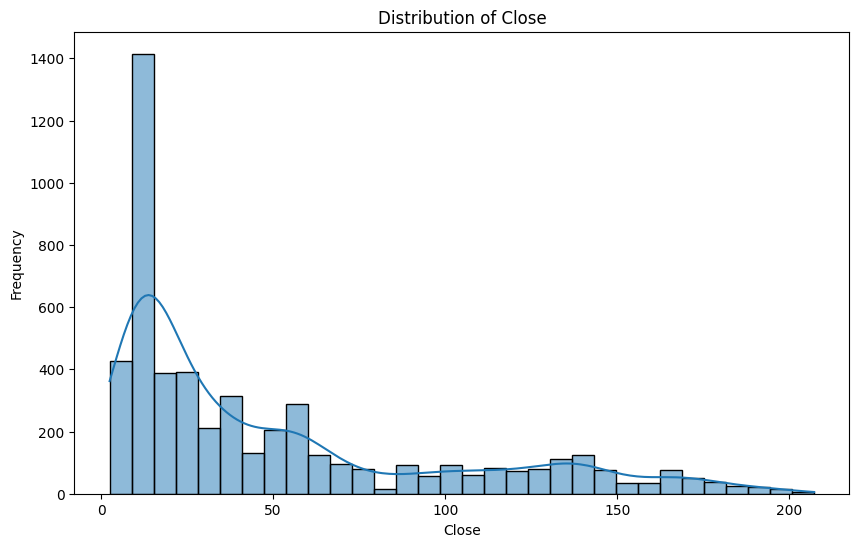

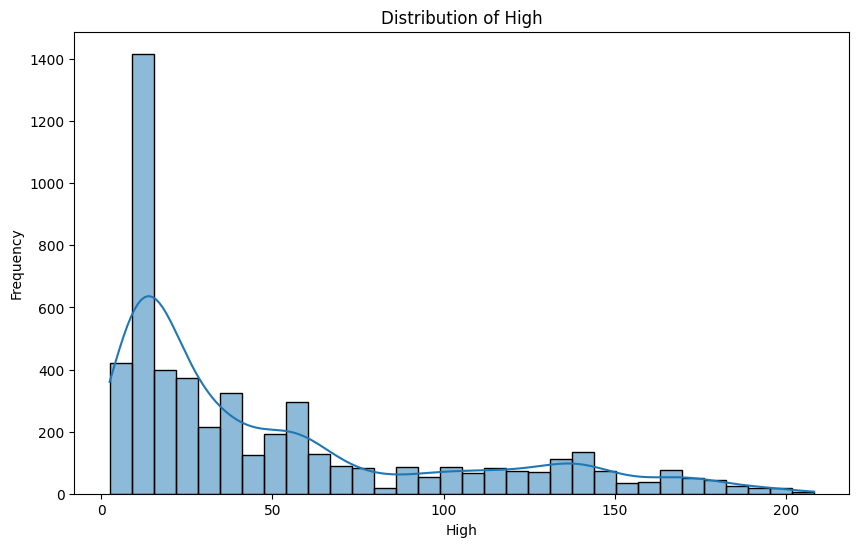

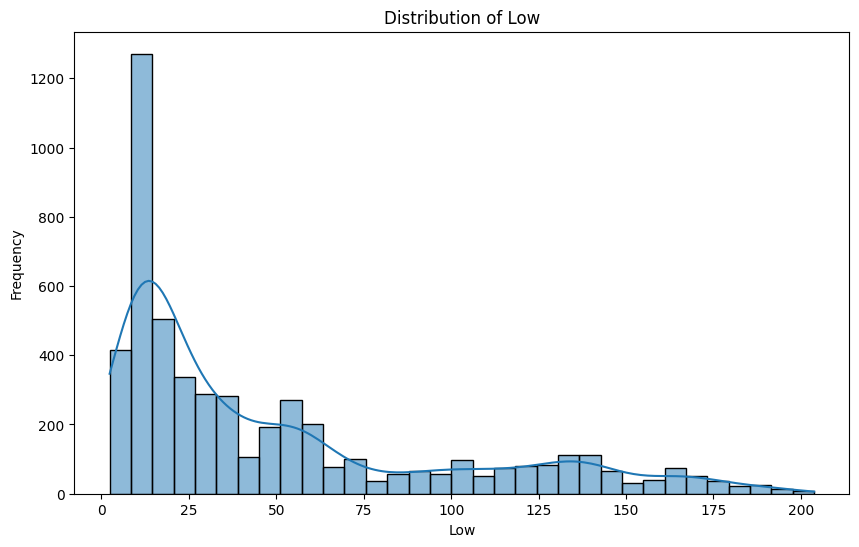

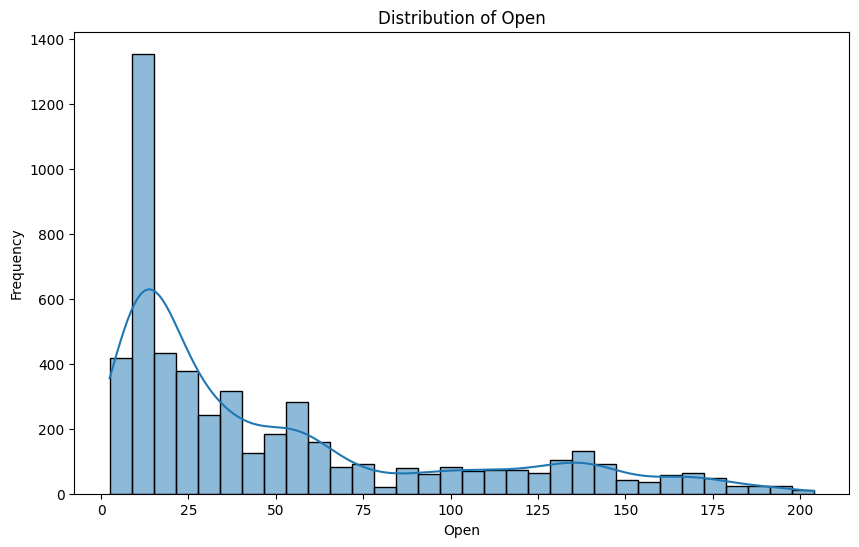

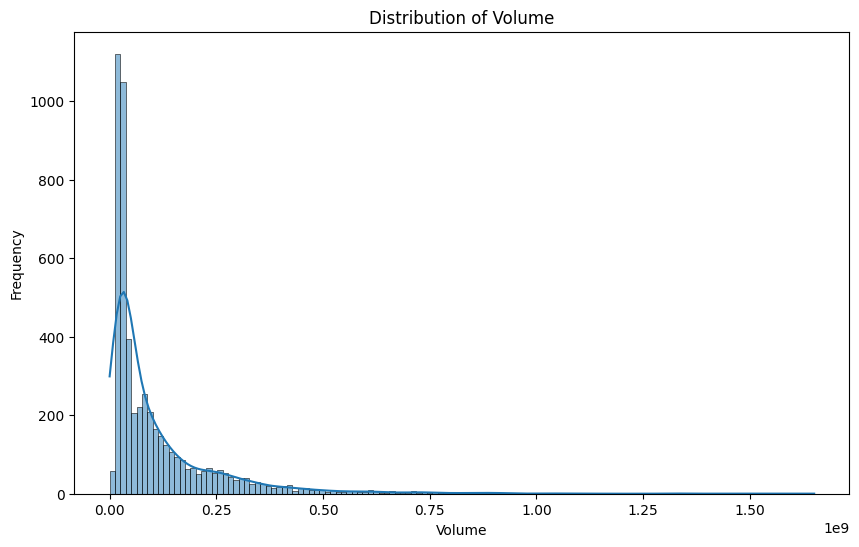

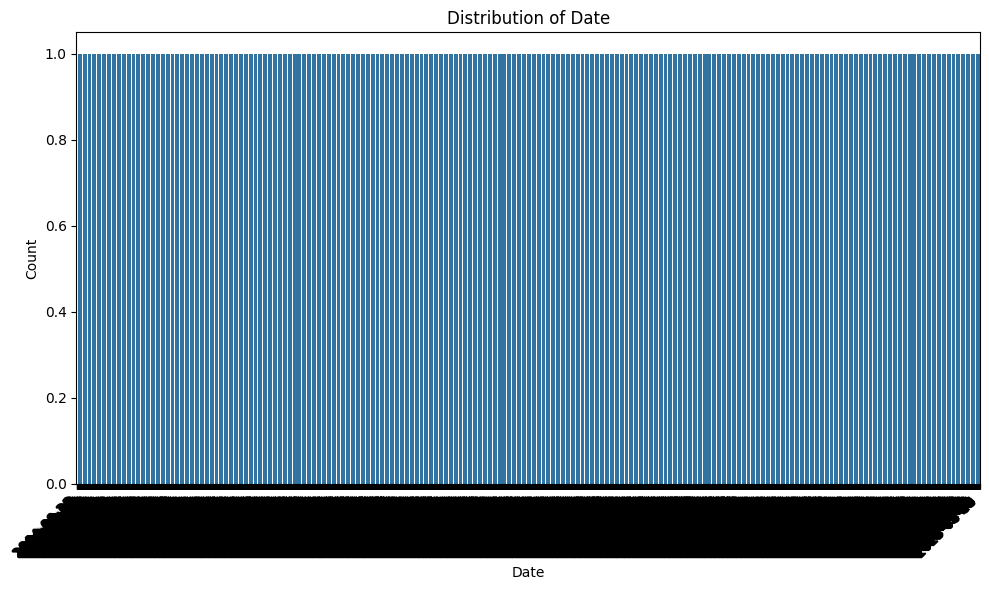

Value counts for Date:
Date
2025-06-10    1
2004-08-19    1
2004-08-20    1
2004-08-23    1
2025-05-16    1
             ..
2004-08-31    1
2004-08-30    1
2004-08-27    1
2004-08-26    1
2004-08-25    1
Name: count, Length: 5236, dtype: int64



In [32]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

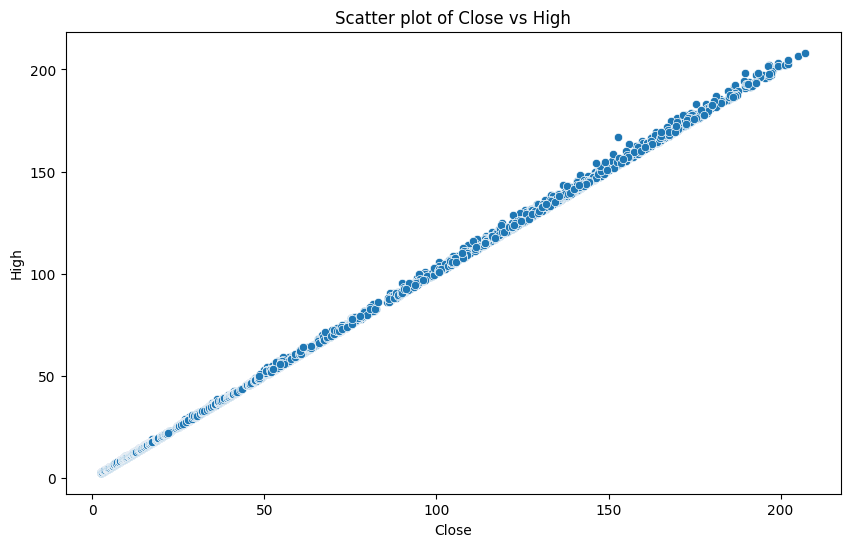

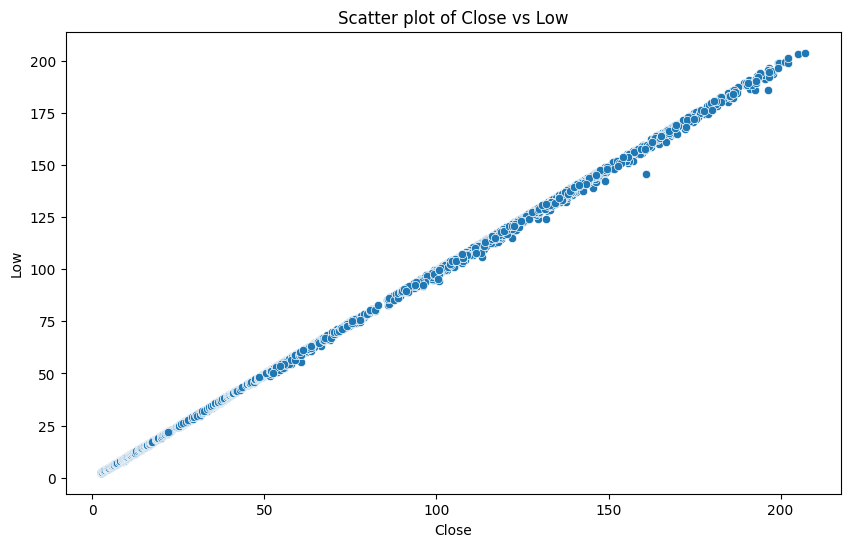

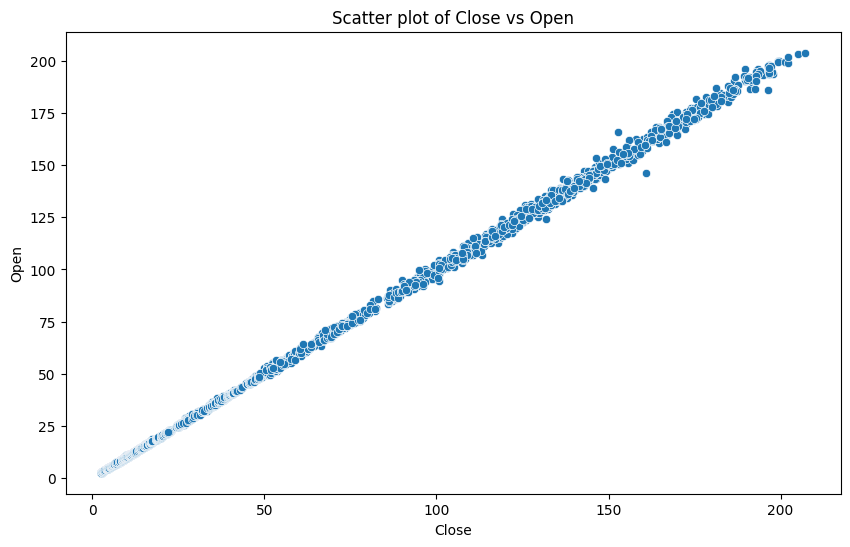

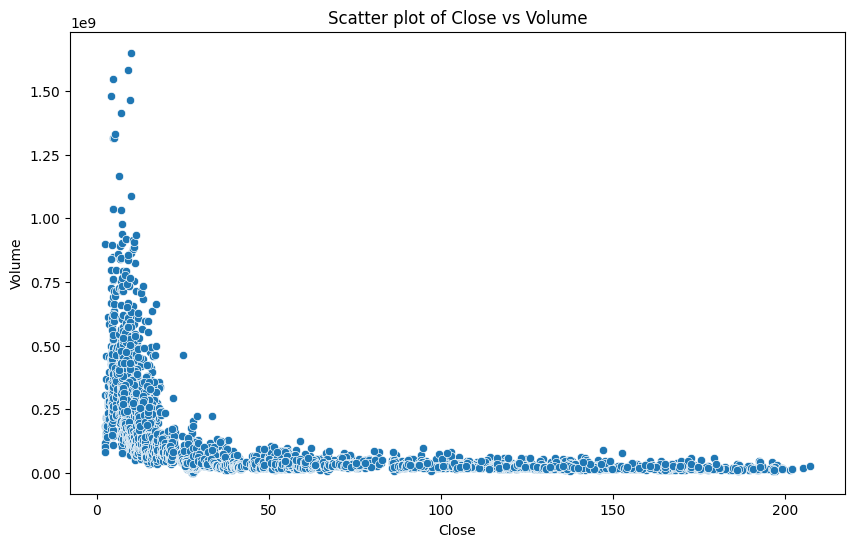

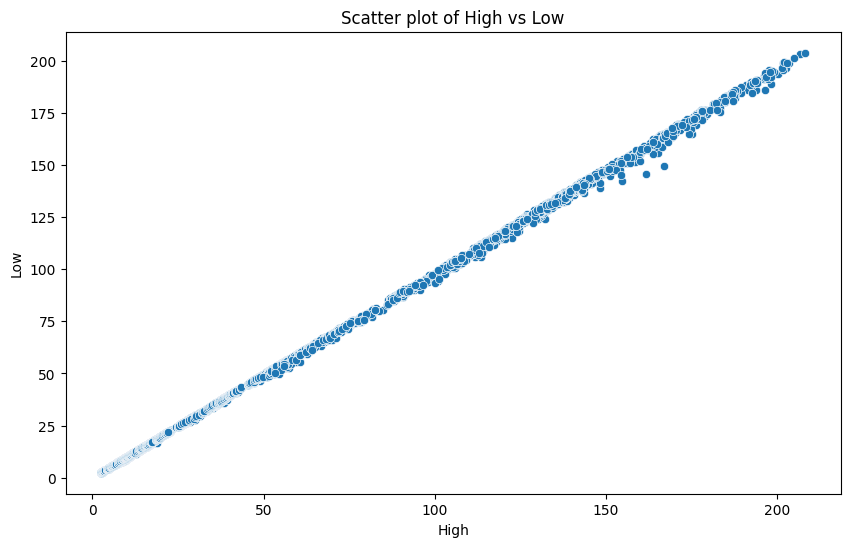

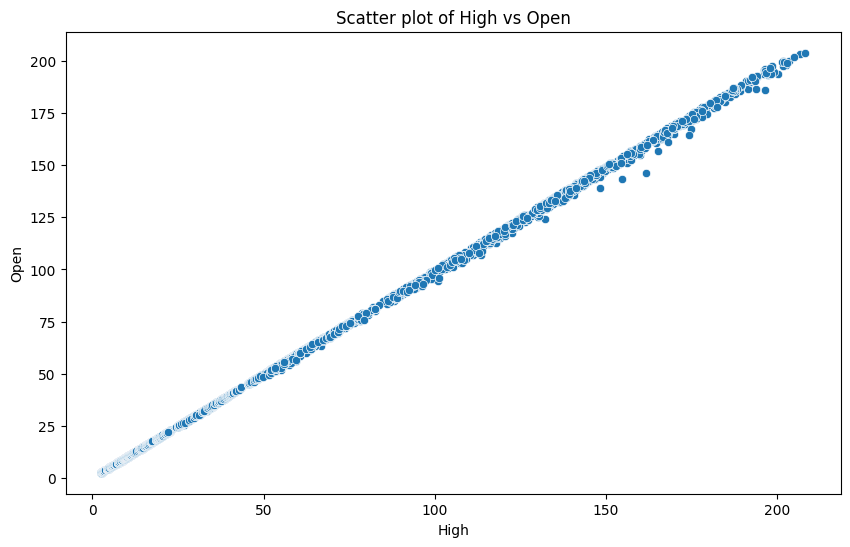

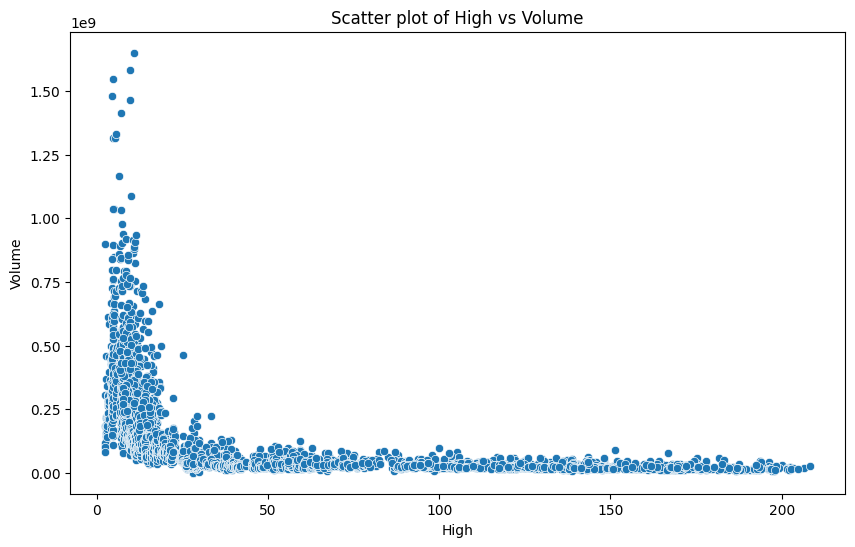

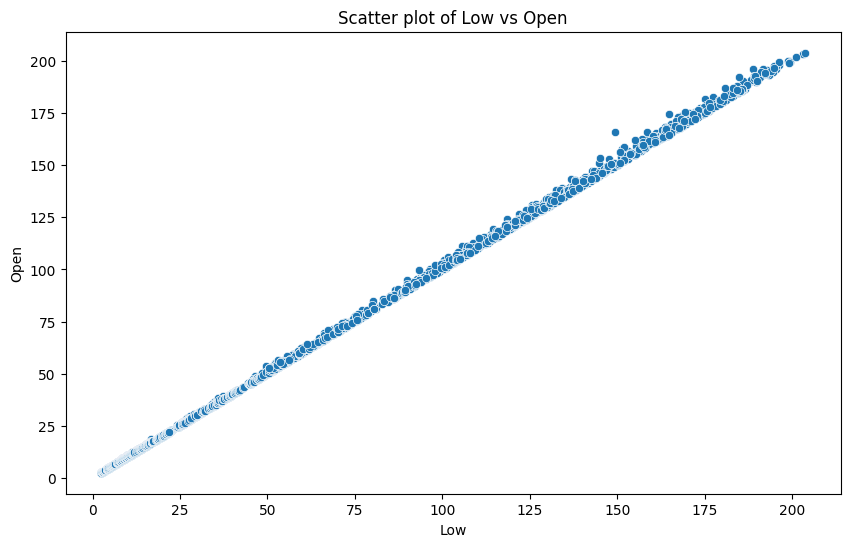

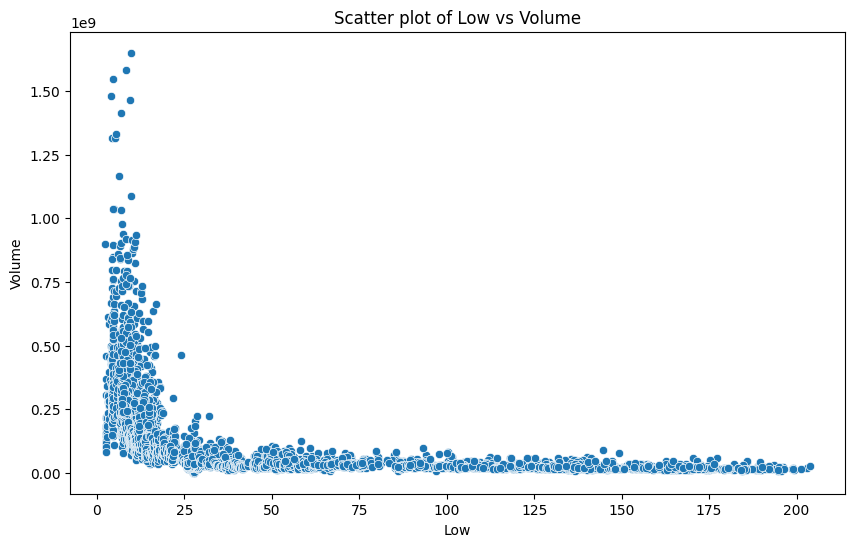

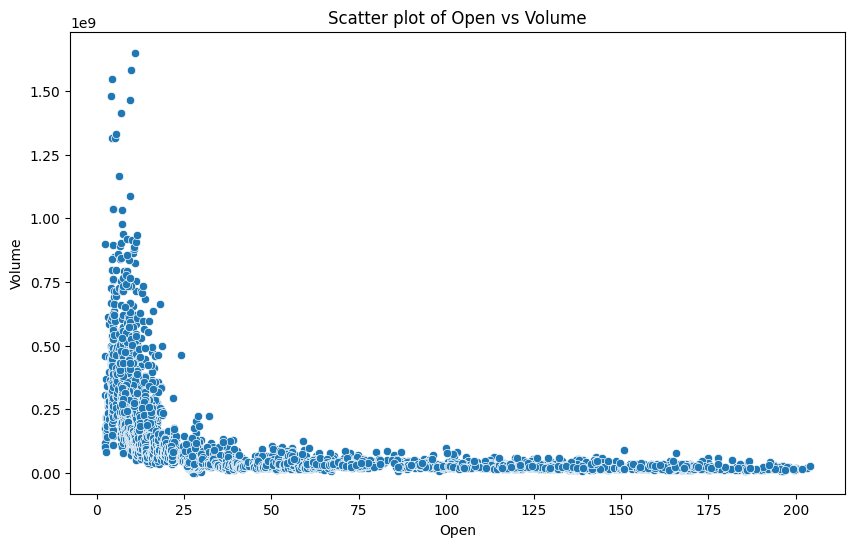

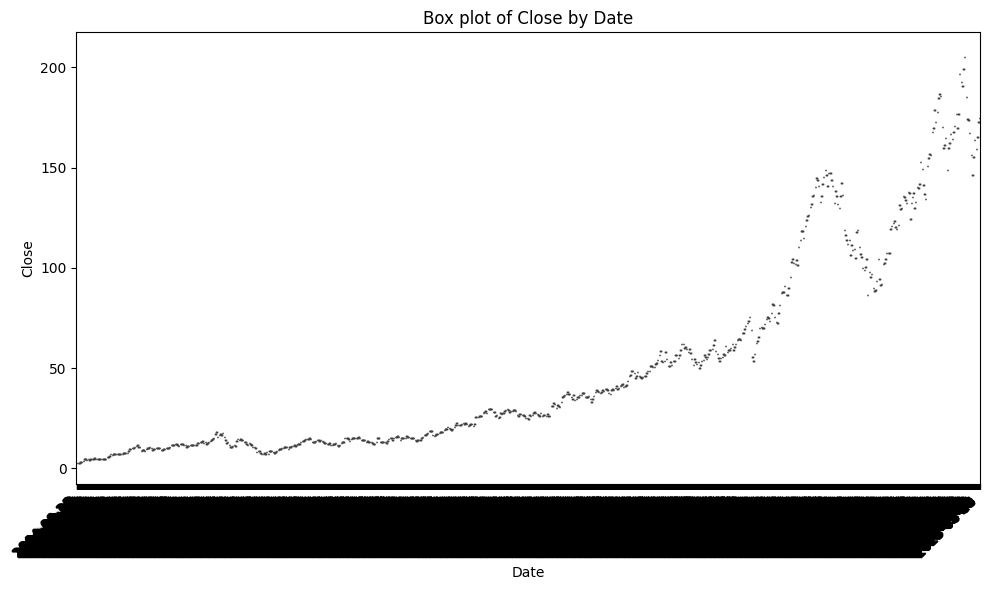

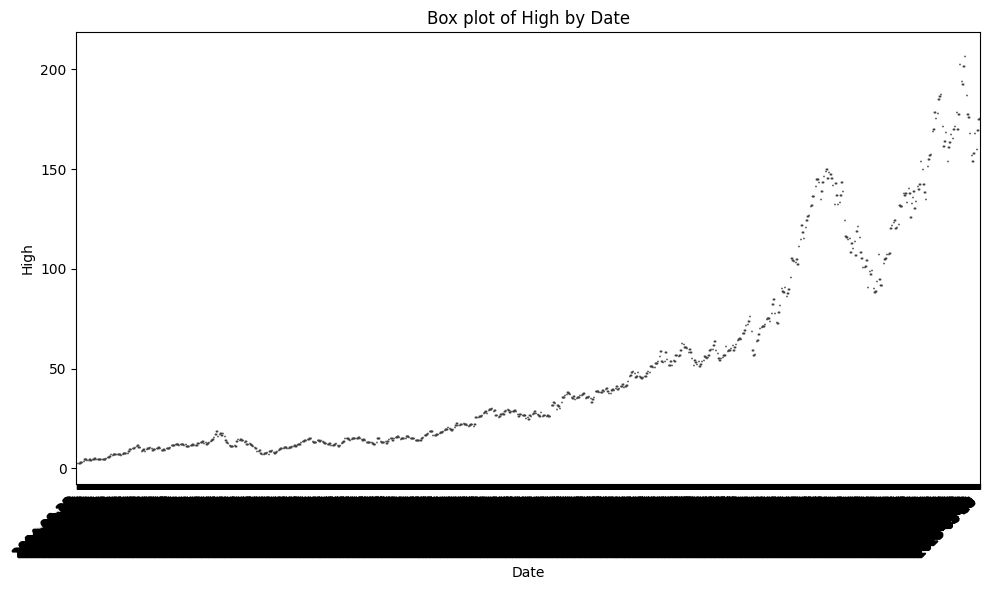

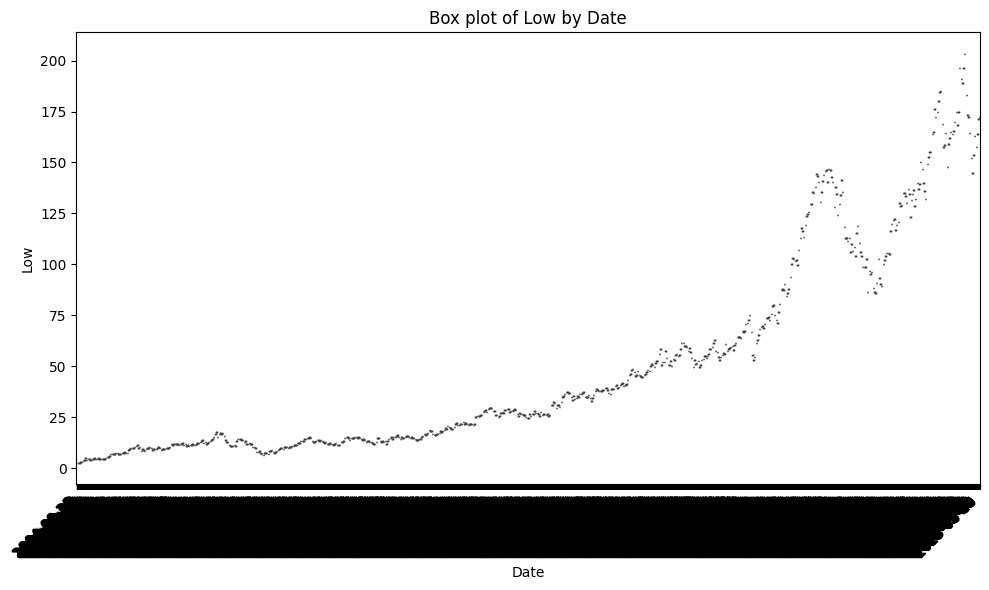

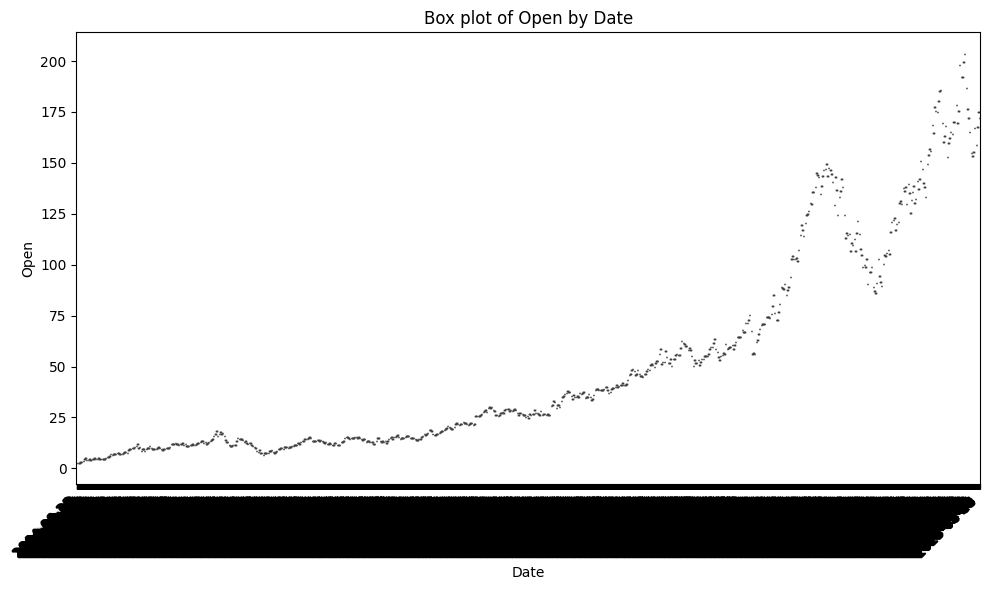

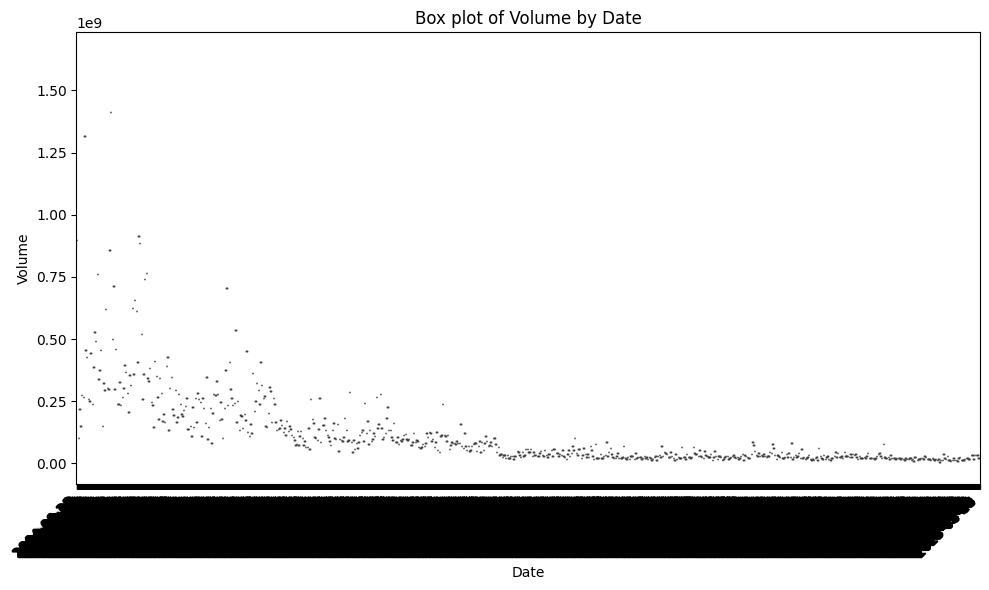

In [33]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

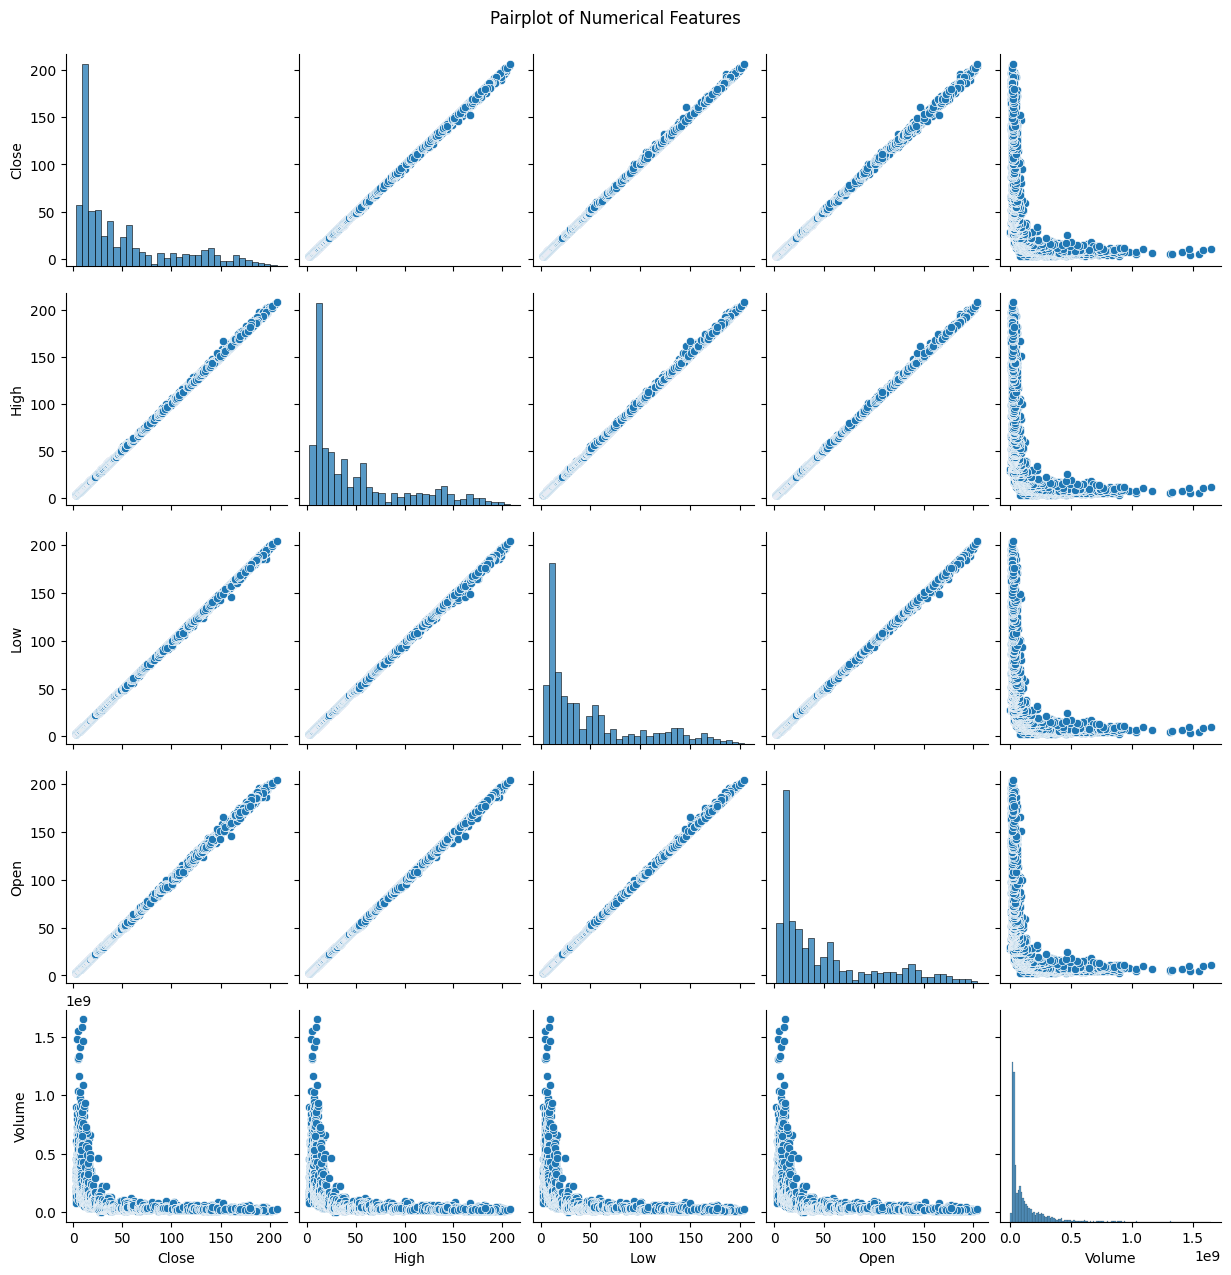

In [35]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

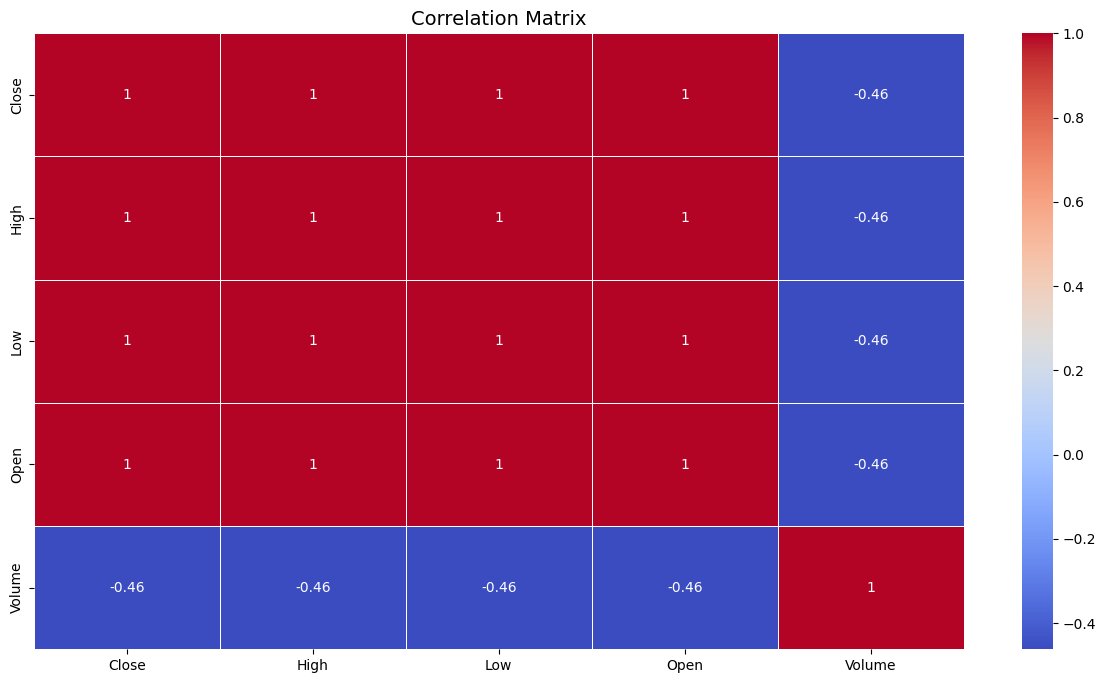

In [34]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you